In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MaxNLocator 
import matplotlib.patheffects as pe
from scipy.integrate import solve_ivp
import matplotlib as mpl
from dataclasses import dataclass
import os


mpl.rcParams.update({
    "text.usetex": False,       # keep your sizes stable
    "mathtext.fontset": "cm",   # Computer Modern for math only
    # keep your normal font choice as-is (optional)
    # "font.family": "sans-serif",
    # "font.sans-serif": ["DejaVu Sans"],
})

## Fig 1. No feedback baseline (fixed game)

### Baseline game with no environmental feedback

$$M = \begin{bmatrix}
0 & \beta \\
\alpha & 0
\end{bmatrix}
$$

\begin{eqnarray}
\dot{x} = x(1-x)(-(\alpha+\beta)x+\alpha)
\end{eqnarray}

#### Panel A. Stability diagram in the payoff-parameter space ($\alpha, \beta$)

In [2]:
# phase diagram
def classify(alpha, beta):
    """Output:
       0 -> strategy 1 dominates (x=0 stable)
       1 -> strategy 2 dominates (x=1 stable)
       2 -> coexistence (interior stable)
       3 -> coordination/bistability (0 and 1 stable)
      -1 -> on axes (alpha=0 or beta=0)
    """
    if alpha < 0 and beta > 0:
        return 0
    if alpha > 0 and beta < 0:
        return 1
    if alpha > 0 and beta > 0:
        return 2
    if alpha < 0 and beta < 0:
        return 3
    return -1

A = np.linspace(-1, 1, 201)
B = np.linspace(-1, 1, 201)
AA, BB = np.meshgrid(A, B)
Z = np.zeros_like(AA, dtype=float)
for i in range(AA.shape[0]):
    for j in range(AA.shape[1]):
        Z[i, j] = classify(AA[i, j], BB[i, j])

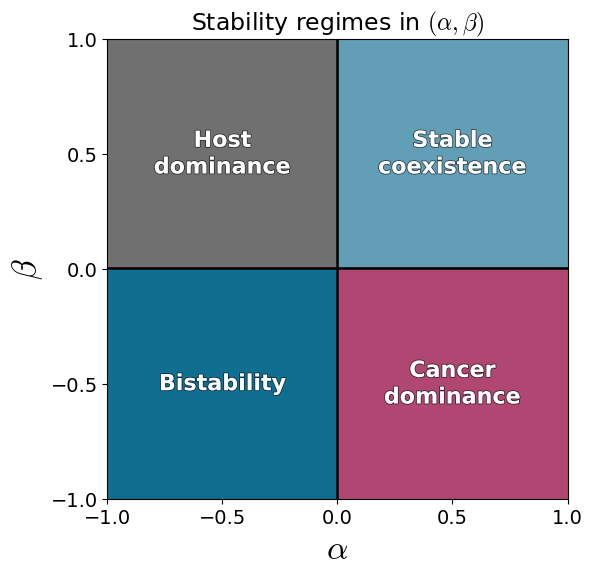

In [3]:
COL_HOST    = "#707071"   # host dominance
COL_COEX    = "#629FB7"   # stable coexistence
COL_BISTAB  = "#106E91"   # bistability
COL_CANCER  = "#AF4772"   # cancer dominance

# 0 host dom, 1 cancer dom, 2 coexist, 3 bistability
cmap = ListedColormap([COL_HOST, COL_CANCER, COL_COEX, COL_BISTAB])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

Z_masked = Z.astype(float)
Z_masked[Z_masked < 0] = np.nan  # hide alpha=0 or beta=0 cells

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(
    Z_masked,
    origin="lower",
    extent=[A.min(), A.max(), B.min(), B.max()],
    aspect="equal",
    cmap=cmap,
    norm=norm,
    interpolation="nearest"
)

ax.axhline(0.001, linewidth=2, color='black')
ax.axvline(0, linewidth=2, color='black')
ax.set(xticks=np.arange(-1, 1.1, 0.5),
       yticks=np.arange(-1, 1.1, 0.5)
      )
ax.set_title(r'Stability regimes in $(\alpha,\beta)$',fontsize=17)
ax.set_xlabel(r'$\alpha$', fontsize=24)
ax.set_ylabel(r'$\beta$', fontsize=24)
ax.tick_params(axis='both', labelsize=14)

# text
txt_kw = dict(
    fontsize=16, color="white", ha="center", va="center", fontweight="semibold",
    path_effects=[pe.withStroke(linewidth=1.2, foreground=(0,0,0,0.6))]
)

ax.text(-0.5,  0.5, "Host\ndominance", **txt_kw)
ax.text( 0.5,  0.5, "Stable\ncoexistence", **txt_kw)
ax.text(-0.5, -0.5, "Bistability", **txt_kw)
ax.text( 0.5, -0.5, "Cancer\ndominance", **txt_kw)

plt.tight_layout()
plt.savefig('Figures/fig1A_phase_alpha_beta.png', dpi=600, bbox_inches="tight")
plt.savefig('Figures/fig1A_phase_alpha_beta.svg', bbox_inches="tight")
plt.show()

#### Panel B. $x(t)$ trajectories

In [12]:
def rhs(t, x, alpha, beta):
    x = x[0]
    dx = x*(1-x)*(alpha - (alpha+beta)*x)
    return [dx]

def sigammalate(alpha, beta, x0, tmax=60, npts=800):
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(rhs, (0, tmax), [x0], t_eval=t_eval,
                    args=(alpha, beta), rtol=1e-8, atol=1e-10)
    return sol.t, sol.y[0]

def x_star(alpha, beta):
    if alpha*beta > 0 and (alpha+beta) != 0:
        xs = alpha/(alpha+beta)
        if 0 < xs < 1:
            return xs
    return None

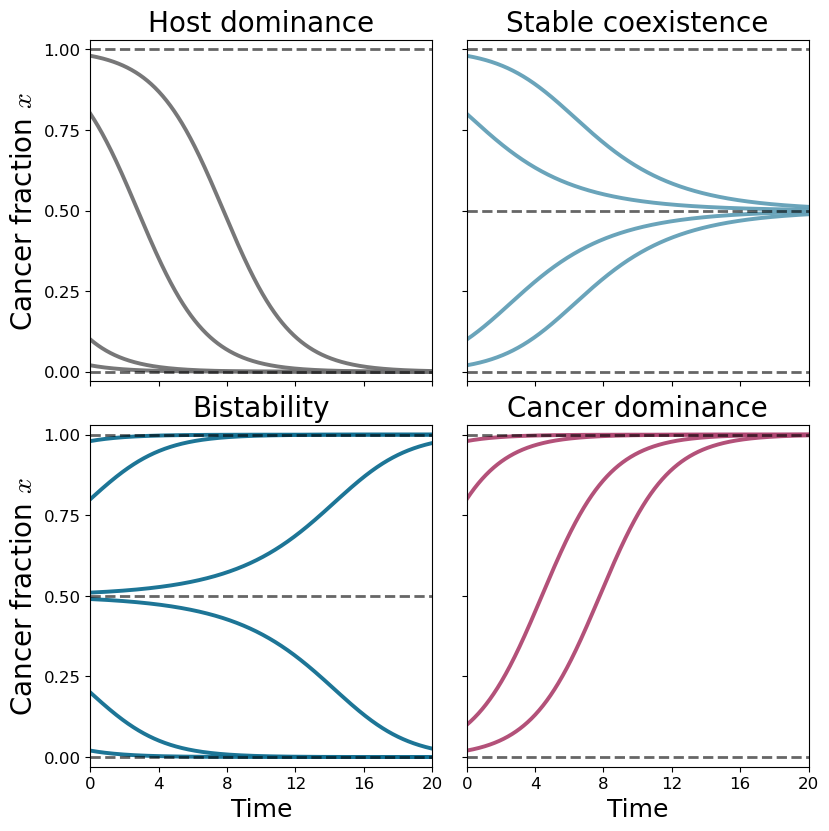

In [13]:
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Representative parameters (one per quadrant)
cases = [
    ("Host dominance",      -0.5, +0.5, COL["host"]),
    ("Stable coexistence",  +0.5, +0.5, COL["coexist"]),
    ("Bistability",         -0.5, -0.5, COL["bistab"]),
    ("Cancer dominance",    +0.5, -0.5, COL["cancer"]),
]
# Initial conditions (several to show convergence)
x0s_general = [0.02, 0.10, 0.80, 0.98]
# show both basins + "just below/above" the unstable point (~0.5 here)
x0s_bistab  = [0.02, 0.20, 0.49, 0.51, 0.80, 0.98]

# Make Panel B square overall, so each small panel can be square and still large
fig, axs = plt.subplots(2, 2, figsize=(8.2, 8.2), sharex=True, sharey=True, constrained_layout=True)
axs = axs.ravel()

for ax, (name, a, b, color) in zip(axs, cases):
    x0s = x0s_bistab if "Bistability" in name else x0s_general

    for x0 in x0s:
        t, x = sigammalate(a, b, x0, tmax=20)
        ax.plot(t, x, lw=2.8, color=color, alpha=0.95)

    # equilibrium guides (keep subtle)
    ax.axhline(0, ls="--", lw=2, color="black", alpha=0.6)
    ax.axhline(1, ls="--", lw=2, color="black", alpha=0.6)
    xs = x_star(a, b)
    if xs is not None:
        ax.axhline(xs, ls="--", lw=2, color="black", alpha=0.6)

    ax.set_title(name, fontsize=20, pad=6)
    ax.set_xlim(0, 20)
    ax.set_ylim(-0.03, 1.03)

    # square subplot boxes
    ax.set_box_aspect(1)

    # integer-ish ticks on time, clean y ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(labelsize=12)

# axis labels (outer only)
axs[2].set_xlabel("Time", fontsize=18)
axs[3].set_xlabel("Time", fontsize=18)
axs[0].set_ylabel(r"Cancer fraction $x$", fontsize=20)
axs[2].set_ylabel(r"Cancer fraction $x$", fontsize=20)

plt.savefig("Figures/fig1B_trajectories.svg", bbox_inches="tight")
plt.savefig("Figures/fig1B_trajectories.png", dpi=600, bbox_inches="tight")

plt.show()


## Fig 3. Environmental feedback trajectories

In [30]:
# ----------------------------
# Core model building blocks
# ----------------------------

@dataclass(frozen=True)
class GameEndpoints:
    """
    Reduced 2x2 payoff form:
        M = [[0, beta],
             [alpha, 0]]

    Endpoints:
      (alpha_h, beta_h) = baseline (low conditioning)
      (alpha_s, beta_s) = stressed (high conditioning)
    """
    alpha_h: float
    beta_h: float
    alpha_s: float
    beta_s: float


def endpoints_host_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 1 mapping:
      baseline: host-dominant  (alpha<0, beta>0)
      stressed: cancer-dominant (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=-alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def endpoints_coexist_to_cancer(alpha: float, beta: float) -> GameEndpoints:
    """
    Scenario 2 mapping:
      baseline: stable coexistence (alpha>0, beta>0)
      stressed: cancer-dominant    (alpha>0, beta<0)
    """
    return GameEndpoints(alpha_h=+alpha, beta_h=+beta,
                         alpha_s=+alpha, beta_s=-beta)


def hill_gate(n, k: float, nu: float = 1.0):
    """
    f(n) = n^nu / (n^nu + k^nu) in [0,1]
    Vectorized.
    """
    n = np.asarray(n)
    n = np.maximum(n, 0.0)
    return (n**nu) / (n**nu + k**nu)


def alpha_beta(n, ends: GameEndpoints, k: float, nu: float = 1.0):
    """
    alpha(n) and beta(n) via interpolation:
      alpha(n) = (1-f) alpha_h + f alpha_s
      beta(n)  = (1-f) beta_h  + f beta_s
    Returns alpha, beta, f (all vectorized).
    """
    f = hill_gate(n, k, nu)
    alpha_n = (1 - f) * ends.alpha_h + f * ends.alpha_s
    beta_n  = (1 - f) * ends.beta_h  + f * ends.beta_s
    return alpha_n, beta_n, f


def rhs(t, y, ends: GameEndpoints, phi: float, gamma: float, k: float, nu: float):
    """
    y = [x, n]
      xdot = x(1-x)( alpha(n) - (alpha(n)+beta(n)) x )
      ndot = phi*x - gamma*n
    """
    x, n = y

    # keep numerics sane (doesn't change the math in practice)
    x = np.clip(x, 0.0, 1.0)
    n = max(n, 0.0)

    a, b, _ = alpha_beta(n, ends, k, nu)
    dx = x * (1 - x) * (a - (a + b) * x)
    dn = phi * x - gamma * n
    return [dx, dn]


def sigammalate_case(ends: GameEndpoints,
                  phi: float, gamma: float, k: float, nu: float,
                  x0: float, n0: float,
                  tmax: float = 80.0, npts: int = 2000):
    """
    Returns a dict with:
      t, x, n, alpha(t), beta(t), f(t)
    """
    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(
        rhs, (0, tmax), [x0, n0], t_eval=t_eval,
        args=(ends, phi, gamma, k, nu),
        rtol=1e-8, atol=1e-10
    )

    t = sol.t
    x = sol.y[0]
    n = sol.y[1]
    a, b, f = alpha_beta(n, ends, k, nu)

    return {"t": t, "x": x, "n": n, "alpha": a, "beta": b, "f": f}

# ----------------------------
# 4 default cases
# ----------------------------

@dataclass(frozen=True)
class Case:
    name: str
    ends: GameEndpoints
    phi: float
    gamma: float
    k: float
    nu: float
    tmax: float
    x0s: tuple
    n0: float


def build_default_cases():
    cases = {}

    # 1) Clearance (Scenario 1, rho_hat<1)
    cases["clearance"] = Case(
        name="Clearance",
        ends=endpoints_host_to_cancer(alpha=0.25, beta=0.5),
        phi=0.7, gamma=0.5, k=2.0, nu=1.0,
        tmax=80.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 2) Stable dormancy / persistence (Scenario 2, rho_hat<1)
    cases["dormancy"] = Case(
        name="Stable dormancy",
        ends=endpoints_coexist_to_cancer(alpha=0.5, beta=0.5),
        phi=0.7, gamma=1.0, k=2.0, nu=1.0,
        tmax=50.0,
        x0s=(0.02, 0.10, 0.80, 0.98),
        n0=0.0
    )

    # 3) Awakening (Scenario 2, rho_hat>1)
    cases["awakening"] = Case(
        name="Awakening",
        ends=endpoints_coexist_to_cancer(alpha=0.1, beta=0.9),
        phi=0.09, gamma=0.02, k=2.0, nu=1.0,
        tmax=720.0,
        x0s=(0.02, 0.10, 0.40, 0.80),
        n0=0.0
    )

    # 4) Primed niche / invasion threshold (Scenario 1, rho_hat>1)
    # Show two initial conditions (your notebook: x0=0.2 vs 0.4)
    cases["primed_threshold"] = Case(
        name="Primed niche threshold",
        ends=endpoints_host_to_cancer(alpha=0.5, beta=0.6),
        phi=0.23, gamma=0.5, k=0.1, nu=1.0,
        tmax=50.0,
        x0s=(0.20, 0.40),
        n0=0.1
    )

    return cases

In [17]:
# 1. clearance
alpha = 0.25
beta = 0.5
phi = 0.7
gamma = 0.5
k = 2
rho_hat = phi / (gamma * k)
print(f"rho_hat = {rho_hat}")
print(f"alpha={alpha}, beta={beta}")

# lab meeting
#alpha = 0.5
#beta = 0.5
#eps = 0.16
#mu = 0.32
#k = 1

rho_hat = 0.7
alpha=0.25, beta=0.5


In [18]:
# 2. stable dormancy
alpha = 0.5
beta = 0.5
phi = 0.7
gamma = 1
k = 2
rho_hat = phi / (gamma * k)
print(f"rho_hat = {rho_hat}")
print(f"alpha={alpha}, beta={beta}")

# lab meeting
#alpha = 0.1
#beta = 0.3
#eps = 0.04
#mu = 0.08
#k = 1

rho_hat = 0.35
alpha=0.5, beta=0.5


In [15]:
# 3. awakening (same as lab meeting)
alpha = 0.1
beta = 0.9
phi = 0.09
gamma = 0.02
k = 2
rho_hat = phi / (gamma * k)
print(f"rho_hat = {rho_hat}")
print(f"alpha={alpha}, beta={beta}")

rho_hat = 2.25
alpha=0.1, beta=0.9


In [19]:
# 4. primed niche (same as lab meeting)
alpha = 0.5
beta = 0.6
phi = 0.23
gamma = 0.5
k = 0.1
rho_hat = phi / (gamma * k)
print(f"rho_hat = {rho_hat}")
print(f"alpha={alpha}, beta={beta}")

rho_hat = 4.6
alpha=0.5, beta=0.6


In [21]:
# Match Fig1 palette
COL = {
    "host":    "#707071",
    "coexist": "#629FB7",
    "bistab":  "#106E91",
    "cancer":  "#AF4772",
}

# Choose one color per feedback case (feel free to change)
CASE_COLOR = {
    "clearance":        COL["host"],
    "dormancy":         COL["coexist"],
    "awakening":        COL["cancer"],
    "primed_threshold": COL["bistab"],
}

# Style knobs to match Fig1
LINE_W = 2.8
LINE_A = 0.95
DASH_W = 2.0
DASH_A = 0.6
TITLE_FS = 20
LABEL_FS = 20
XLABEL_FS = 18
TICK_FS = 12


def run_case(case, npts=2000):
    """Sigammalate all x0s for a Case. Returns list of dict outputs."""
    outs = []
    for x0 in case.x0s:
        out = sigammalate_case(
            case.ends,
            phi=case.phi, gamma=case.gamma, k=case.k, nu=case.nu,
            x0=x0, n0=case.n0,
            tmax=case.tmax, npts=npts
        )
        out["x0"] = x0
        outs.append(out)
    return outs


def _nice_ylim_n(case, outs):
    """Choose n-axis limits that always show 0 and the tolerance k line."""
    nmax = max(float(np.max(o["n"])) for o in outs)
    top = 1.05 * max(nmax, case.k)
    bottom = -0.03 * case.k  # tiny padding like your x axis
    return bottom, top


def plot_case_timeseries(case_key, case, outs, outdir="Figures",
                         layout="stack", label_x0=False):
    """
    Save ONE figure for ONE case.
    layout:
      - "stack": x(t) top, n(t) bottom
      - "twin" : x(t) left axis, n(t) right axis (same panel)
    """
    os.makedirs(outdir, exist_ok=True)
    color = CASE_COLOR.get(case_key, "black")

    if layout == "stack":
        fig, (ax_x, ax_n) = plt.subplots(
            2, 1, figsize=(6.2, 6.2), sharex=True, constrained_layout=True
        )

        # --- x(t) ---
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
            if label_x0:
                ax_x.text(o["t"][int(0.03*len(o["t"]))], o["x"][int(0.03*len(o["x"]))],
                          f"{o['x0']:.2f}", fontsize=10, color=color)

        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)
        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)

        # --- n(t) ---
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color=color, alpha=LINE_A)

        # tolerance line at n = k
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)
        ax_n.set_xlabel("Time", fontsize=XLABEL_FS)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        # ticks (integer time, clean y)
        ax_n.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)

        # Save
        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    elif layout == "twin":
        fig, ax_x = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax_n = ax_x.twinx()

        # x(t)
        for o in outs:
            ax_x.plot(o["t"], o["x"], lw=LINE_W, color=color, alpha=LINE_A)
        ax_x.axhline(0, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.axhline(1, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        ax_x.set_ylim(-0.03, 1.03)

        # n(t)
        for o in outs:
            ax_n.plot(o["t"], o["n"], lw=LINE_W, color="black", alpha=0.35)
        ax_n.axhline(case.k, ls="--", lw=DASH_W, color="black", alpha=DASH_A)
        nlo, nhi = _nice_ylim_n(case, outs)
        ax_n.set_ylim(nlo, nhi)

        ax_x.set_title(case.name, fontsize=TITLE_FS, pad=6)
        ax_x.set_xlabel("Time", fontsize=XLABEL_FS)
        ax_x.set_ylabel(r"Cancer fraction $x$", fontsize=LABEL_FS)
        ax_n.set_ylabel(r"Conditioning $n$", fontsize=LABEL_FS)

        ax_x.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
        ax_x.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_n.yaxis.set_major_locator(MaxNLocator(nbins=5))
        ax_x.tick_params(labelsize=TICK_FS)
        ax_n.tick_params(labelsize=TICK_FS)

        base = os.path.join(outdir, f"fig3_{case_key}_{layout}")
        fig.savefig(base + ".svg", bbox_inches="tight")
        fig.savefig(base + ".png", dpi=600, bbox_inches="tight")
        plt.show()
        return base

    else:
        raise ValueError("layout gammast be 'stack' or 'twin'")




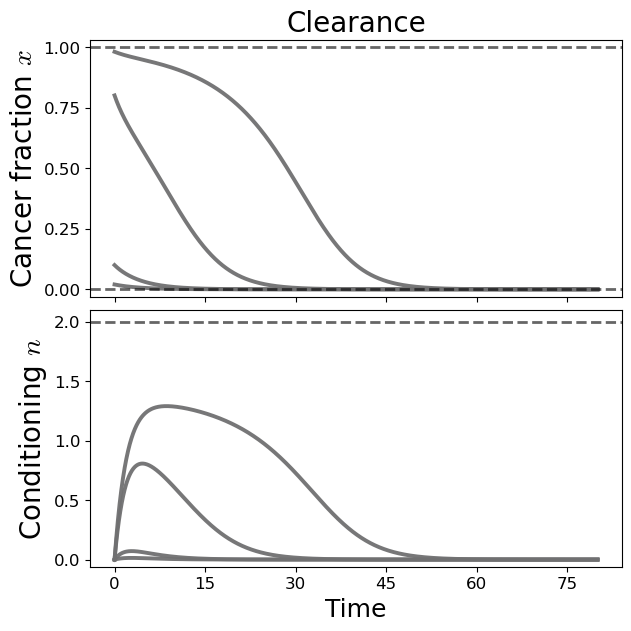

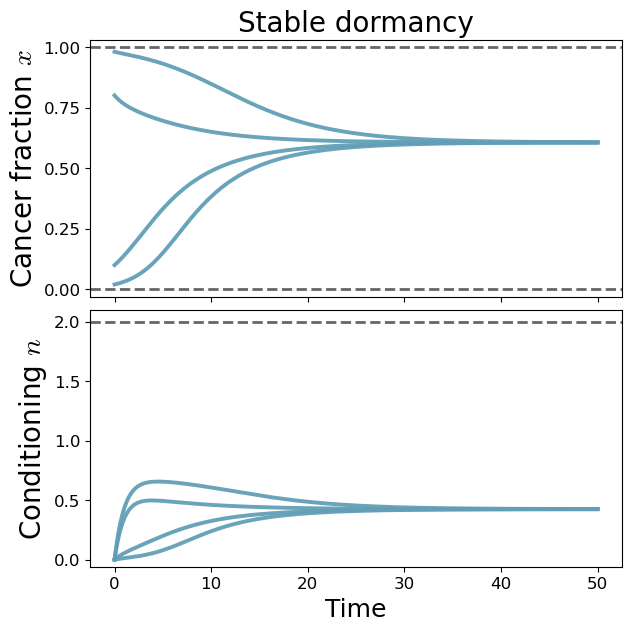

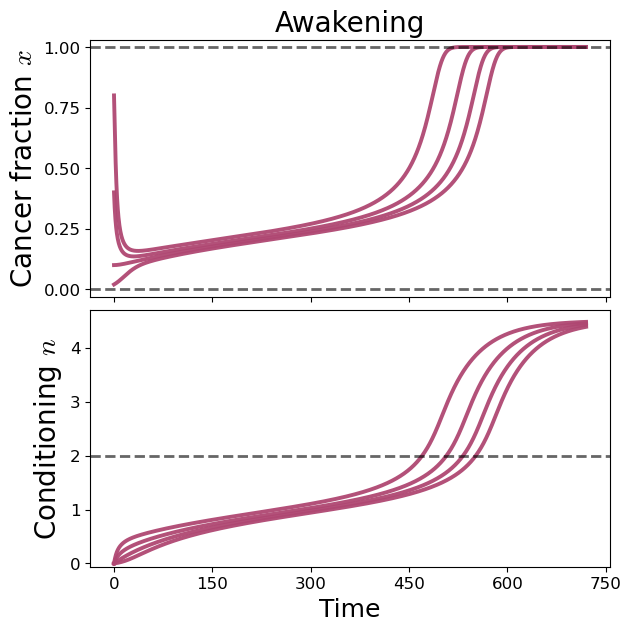

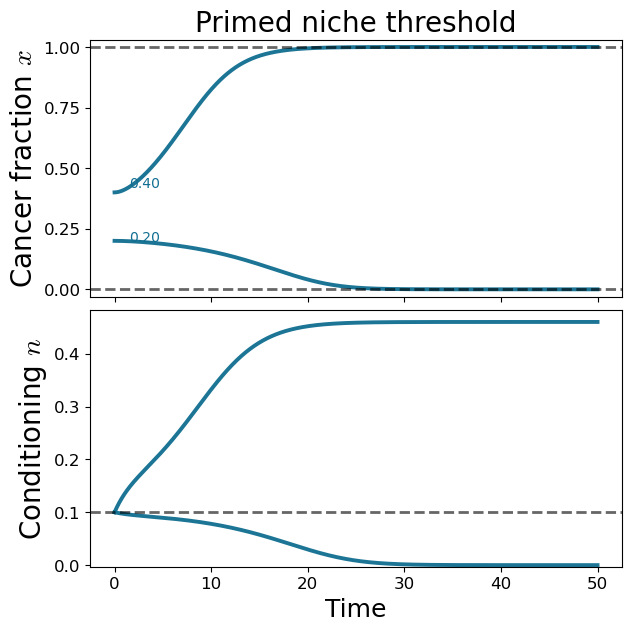

In [31]:
# -------------------------
# Example usage
# -------------------------
cases = build_default_cases()

# one-by-one (recommended)
for key in ["clearance", "dormancy", "awakening", "primed_threshold"]:
    case = cases[key]
    outs = run_case(case, npts=2000)

    # stacked plots (x above, n below)
    # layout = stack OR twin
    plot_case_timeseries(key, case, outs, outdir="Figures", layout="stack",
                         label_x0=(key == "primed_threshold"))

    # If twin-axis versions too:
    #plot_case_timeseries("awakening", cases["awakening"], run_case(cases["awakening"]),
    #                  outdir="Figures", layout="twin")
